# 03 Exploratory Data Analysis

## Diabetes Glucose Time-Series Analysis

This notebook performs exploratory data analysis on the cleaned and processed HUPA-UCM Diabetes Dataset.

The processed dataset was created in Notebook 2 and contains patient-level time-series records at 5-minute intervals.

The purpose of this notebook is to understand:

- overall glucose distribution
- glucose category patterns
- patient-level glucose behavior
- glucose variation across time
- relationships between glucose and features such as activity, calories, insulin, and carbohydrate intake
- usefulness of lag and rolling features for future modeling

This notebook focuses on analytical exploration, visualization, interpretation, and storytelling.

### Why this step is important

A clear notebook title and purpose explain what the notebook does and how it fits into the overall project workflow. This makes the project easier to understand for recruiters, reviewers, and future users.

### Consequence if skipped

If this section is skipped, the notebook may look like a collection of random code cells without a clear analytical goal.

## 1. Import Required Libraries

In this section, the required Python libraries are imported.

- `pandas` and `numpy` are used for data manipulation and numerical operations.
- `matplotlib` and `seaborn` are used for data visualization.
- `os` is used to create folders and manage file paths.

In [113]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
plt.style.use("ggplot")
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Chart Style
sns.set_style("whitegrid")

# Default Figure Size
plt.rcParams['figure.figsize'] = (12,6)

# Automatic Color Palette
sns.set_palette("Set2")

# Better Resolution
plt.rcParams["figure.dpi"] = 100

### Visualization Settings Code

In [114]:
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

### Why this step is important

Importing libraries at the beginning keeps the notebook organized and makes it clear which tools are being used. Visualization settings help keep all plots consistent, readable, and professional.

### Consequence if skipped

If required libraries are not imported, later code cells will fail. If visualization settings are skipped, plots may still work, but they may look inconsistent or less professional.

## 2. Load Processed Dataset

The cleaned and processed dataset created in Notebook 2 is loaded here.

Two files are used:

- `diabetes_glucose_processed.csv`: main processed time-series dataset
- `patient_summary.csv`: patient-level summary dataset

Using the processed files avoids repeating cleaning and preprocessing steps from earlier notebooks.

In [115]:
processed_path = "../data/processed/diabetes_glucose_processed.csv"
summary_path = "../data/processed/patient_summary.csv"

df = pd.read_csv(processed_path)
patient_summary = pd.read_csv(summary_path)

In [116]:
df.head()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id,time_diff,glucose_category,hour,day,day_of_week,date,time_period,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_rolling_30min,glucose_rolling_1hr
0,2018-06-13 19:10:00,312.0,10.1430,91.339623,48.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,high,19,13,2,2018-06-13,evening,313.0,324.0,332.0,318.500000,320.428571
1,2018-06-13 19:15:00,293.0,6.8425,89.893443,0.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,high,19,13,2,2018-06-13,evening,312.0,306.0,326.0,313.000000,317.000000
2,2018-06-13 19:20:00,303.0,5.2325,89.352941,0.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,high,19,13,2,2018-06-13,evening,293.0,313.0,330.0,308.500000,315.444444
3,2018-06-13 19:25:00,293.0,8.0500,89.778761,77.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,high,19,13,2,2018-06-13,evening,303.0,312.0,324.0,303.333333,313.200000
4,2018-06-13 19:30:00,271.0,17.7905,104.536232,124.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,high,19,13,2,2018-06-13,evening,293.0,293.0,306.0,297.500000,309.363636


In [117]:
patient_summary.head()

,patient_id,start_time,end_time,total_records,avg_glucose,min_glucose,max_glucose
0,HUPA0001P,2018-06-13 19:10:00,2018-06-27 23:55:00,4090,181.237775,40.0,444.0
1,HUPA0002P,2018-06-13 23:15:00,2018-06-24 23:45:00,3175,113.534173,40.0,310.0
2,HUPA0003P,2018-06-13 22:10:00,2018-06-26 23:45:00,3764,143.285113,44.0,366.0
3,HUPA0004P,2018-07-09 16:00:00,2018-07-20 16:45:00,3178,180.379327,40.0,411.0
4,HUPA0005P,2018-07-09 14:50:00,2018-07-22 23:45:00,3852,147.628212,40.0,379.0


### Why this step is important

EDA should be performed on the cleaned and processed dataset, not the raw dataset. This ensures that the analysis is based on standardized columns, cleaned missing values, engineered features, and validated time-series records.

### Consequence if skipped

If the processed dataset is not loaded, the notebook cannot continue. If raw data is used by mistake, the analysis may include missing values, inconsistent formats, or unprocessed patient identifiers, which can lead to incorrect conclusions.

## 3. Inspect Dataset Structure

Before starting visual analysis, the dataset structure is inspected.

This includes:

- number of rows and columns
- column names
- data types
- missing values
- basic preview of the dataset

In [118]:
df.shape

(309242, 21)

In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 309242 entries, 0 to 309241
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   time                    309242 non-null  str    
 1   glucose                 309242 non-null  float64
 2   calories                309242 non-null  float64
 3   heart_rate              309242 non-null  float64
 4   steps                   309242 non-null  float64
 5   basal_rate              309242 non-null  float64
 6   bolus_volume_delivered  309242 non-null  float64
 7   carb_input              309242 non-null  float64
 8   patient_id              309242 non-null  str    
 9   time_diff               309242 non-null  str    
 10  glucose_category        309242 non-null  str    
 11  hour                    309242 non-null  int64  
 12  day                     309242 non-null  int64  
 13  day_of_week             309242 non-null  int64  
 14  date                    309242 

In [120]:
df.columns

Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input', 'patient_id', 'time_diff',
       'glucose_category', 'hour', 'day', 'day_of_week', 'date', 'time_period',
       'glucose_lag_1', 'glucose_lag_3', 'glucose_lag_6',
       'glucose_rolling_30min', 'glucose_rolling_1hr'],
      dtype='str')

In [121]:
df.isnull().sum()

time                      0
glucose                   0
calories                  0
heart_rate                0
steps                     0
basal_rate                0
bolus_volume_delivered    0
carb_input                0
patient_id                0
time_diff                 0
glucose_category          0
hour                      0
day                       0
day_of_week               0
date                      0
time_period               0
glucose_lag_1             0
glucose_lag_3             0
glucose_lag_6             0
glucose_rolling_30min     0
glucose_rolling_1hr       0
dtype: int64

### Why this step is important

Even though the data was cleaned in Notebook 2, it is important to verify that the processed dataset loaded correctly. This helps confirm that all expected columns are available before creating visualizations.

### Consequence if skipped

If this step is skipped, errors may appear later due to missing columns, incorrect data types, or unexpected null values. It also becomes harder to debug problems in the notebook.

## 4. Convert Time Column to Datetime

The `time` column is converted back to datetime format.

Although this conversion was already done in Notebook 2, CSV files do not preserve datetime data types. When a CSV file is loaded again, datetime columns are usually read as strings.

In [122]:
df["time"] = pd.to_datetime(df["time"])

In [123]:
df[["time", "patient_id", "glucose"]].head()

,time,patient_id,glucose
0,2018-06-13 19:10:00,HUPA0001P,312.0
1,2018-06-13 19:15:00,HUPA0001P,293.0
2,2018-06-13 19:20:00,HUPA0001P,303.0
3,2018-06-13 19:25:00,HUPA0001P,293.0
4,2018-06-13 19:30:00,HUPA0001P,271.0


In [124]:
df["time"].dtype

dtype('<M8[us]')

### Why this step is important

Datetime conversion is necessary for time-series analysis. It allows the notebook to correctly analyze trends by hour, day, date, and time order.

### Consequence if skipped

If the `time` column remains as a string, time-based analysis may be incorrect or fail. Sorting, grouping, filtering, and plotting by time may not work properly.

## 5. Create Folder for Saving Visualizations

A dedicated folder is created to save plots generated during EDA.

The plots will be saved inside:

`reports/figures`

Saving figures makes the project more professional and allows the visuals to be reused in the README, reports, or presentations.

In [125]:
plots_dir = "../reports/figures"
os.makedirs(plots_dir, exist_ok=True)

### Why this step is important

Saving visualizations creates reusable project assets. These plots can later be added to the GitHub README, final report, or portfolio presentation.

### Consequence if skipped

If plots are not saved, the analysis only exists inside the notebook. This makes it harder to share results outside the notebook or document findings professionally.

## 6. Dataset Overview

This section provides a high-level statistical overview of the processed dataset.

The goal is to understand:

- the size of the dataset
- number of unique patients
- summary statistics for numerical columns
- general range of values in key features

In [126]:
df.shape

(309242, 21)

In [127]:
df["patient_id"].nunique()

25

In [128]:
df.describe()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,hour,day,day_of_week,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_rolling_30min,glucose_rolling_1hr
count,309242,309242.000000,309242.000000,309242.000000,309242.000000,309242.000000,309242.000000,309242.000000,309242.00000,309242.000000,309242.000000,309242.000000,309242.000000,309242.000000,309242.000000,309242.000000
mean,2020-09-24 18:58:07.812134,141.430195,8.812304,76.987333,30.807824,0.041319,0.066025,0.052688,11.52165,15.833037,3.012440,141.428120,141.423948,141.418248,141.425067,141.419239
min,2018-06-13 19:10:00,40.000000,0.000000,32.407773,0.000000,0.000000,-3.000000,0.000000,0.00000,1.000000,0.000000,40.000000,40.000000,40.000000,40.000000,40.000000
25%,2020-01-30 13:30:00,99.666667,5.846100,64.926471,0.000000,0.000000,0.000000,0.000000,6.00000,8.000000,1.000000,99.666667,99.666667,99.666667,99.944444,100.500000
50%,2020-10-31 22:37:30,132.000000,6.278100,75.414634,0.000000,0.056000,0.000000,0.000000,12.00000,16.000000,3.000000,132.000000,132.000000,132.000000,132.166667,132.275116
75%,2021-07-27 09:08:45,173.000000,9.173880,85.610263,11.000000,0.066000,0.000000,0.000000,18.00000,23.000000,5.000000,173.000000,173.000000,173.000000,172.500000,171.833333
max,2022-05-18 12:15:00,444.000000,106.350000,195.615385,842.000000,0.250000,19.800000,130.000000,23.00000,31.000000,6.000000,444.000000,444.000000,444.000000,439.888889,430.652778
std,NaN,57.077809,6.929840,15.546810,84.957500,0.036105,0.754907,1.505663,6.92501,8.651302,1.998963,57.077408,57.076773,57.075878,56.683767,55.872279


In [129]:
df.describe(include="all")

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id,time_diff,glucose_category,hour,day,day_of_week,date,time_period,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_rolling_30min,glucose_rolling_1hr
count,309242,309242.000000,309242.000000,309242.000000,309242.000000,309242.000000,309242.000000,309242.000000,309242,309242,309242,309242.00000,309242.000000,309242.000000,309242,309242,309242.000000,309242.000000,309242.000000,309242.000000,309242.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25,1,3,NaN,NaN,NaN,800,4,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HUPA0027P,0 days 00:05:00,normal,NaN,NaN,NaN,2019-07-04,night,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,165300,309242,221080,NaN,NaN,NaN,1152,103071,NaN,NaN,NaN,NaN,NaN
mean,2020-09-24 18:58:07.812134,141.430195,8.812304,76.987333,30.807824,0.041319,0.066025,0.052688,NaN,NaN,NaN,11.52165,15.833037,3.012440,NaN,NaN,141.428120,141.423948,141.418248,141.425067,141.419239
min,2018-06-13 19:10:00,40.000000,0.000000,32.407773,0.000000,0.000000,-3.000000,0.000000,NaN,NaN,NaN,0.00000,1.000000,0.000000,NaN,NaN,40.000000,40.000000,40.000000,40.000000,40.000000
25%,2020-01-30 13:30:00,99.666667,5.846100,64.926471,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,6.00000,8.000000,1.000000,NaN,NaN,99.666667,99.666667,99.666667,99.944444,100.500000
50%,2020-10-31 22:37:30,132.000000,6.278100,75.414634,0.000000,0.056000,0.000000,0.000000,NaN,NaN,NaN,12.00000,16.000000,3.000000,NaN,NaN,132.000000,132.000000,132.000000,132.166667,132.275116
75%,2021-07-27 09:08:45,173.000000,9.173880,85.610263,11.000000,0.066000,0.000000,0.000000,NaN,NaN,NaN,18.00000,23.000000,5.000000,NaN,NaN,173.000000,173.000000,173.000000,172.500000,171.833333
max,2022-05-18 12:15:00,444.000000,106.350000,195.615385,842.000000,0.250000,19.800000,130.000000,NaN,NaN,NaN,23.00000,31.000000,6.000000,NaN,NaN,444.000000,444.000000,444.000000,439.888889,430.652778


### Observations

The dataset contains multiple patients with time-series glucose records. Each row represents a timestamped observation, and the dataset includes glucose values along with related features such as heart rate, calories, steps, basal insulin, bolus insulin, and carbohydrate input.

The summary statistics provide an initial understanding of the range, average, and spread of numerical features.

### Why this step is important

Summary statistics provide the first numerical understanding of the dataset. They help identify unusual ranges, possible outliers, and differences in scale across features.

### Consequence if skipped

If summary statistics are skipped, the visual analysis may begin without understanding the basic structure and range of the data. This can lead to poor plot choices or missed data quality issues.

# Main EDA

## 7. Glucose Distribution

This section analyzes the overall distribution of glucose values across all patients.

A histogram with a density curve is used to understand:

- the most common glucose ranges
- whether glucose values are normally distributed or skewed
- whether extreme glucose values are present

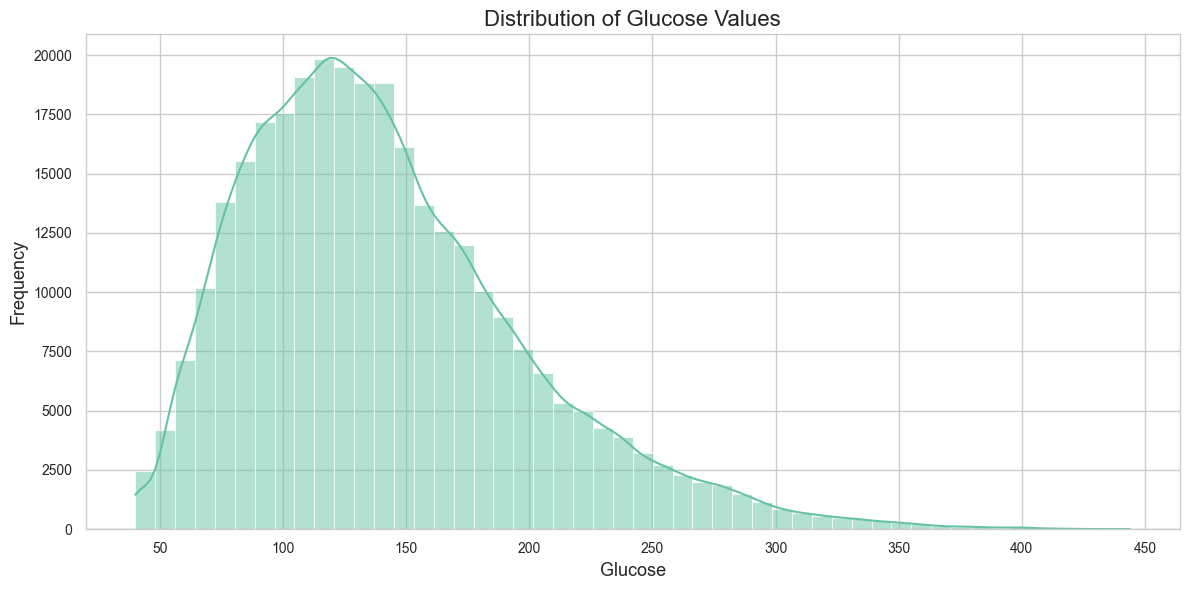

In [130]:
plt.figure(figsize=(12, 6))

sns.histplot(df["glucose"], bins=50, kde=True)

plt.title("Distribution of Glucose Values")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig(f"{plots_dir}/glucose_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The glucose distribution shows how frequently different glucose values occur in the dataset. This helps identify the most common glucose range and whether the dataset contains unusually high or low glucose readings.

If the distribution is right-skewed, it means that higher glucose values occur less frequently but may still be important. These high values may represent hyperglycemic events.

### Why this step is important

Glucose is the main variable of interest in this project. Understanding its distribution is essential before performing patient-level, time-based, or predictive analysis.

### Consequence if skipped

If glucose distribution is skipped, the project misses a basic understanding of the target variable. Later analysis may lack context about whether glucose values are balanced, skewed, or affected by extreme values.

## 8. Glucose Category Analysis

This section analyzes the frequency of glucose categories created during preprocessing.

The purpose is to understand how many readings fall into each glucose category, such as low, normal, high, or very high glucose.

In [131]:
df["glucose_category"].value_counts()

glucose_category
normal    221080
high       67091
low        21071
Name: count, dtype: int64

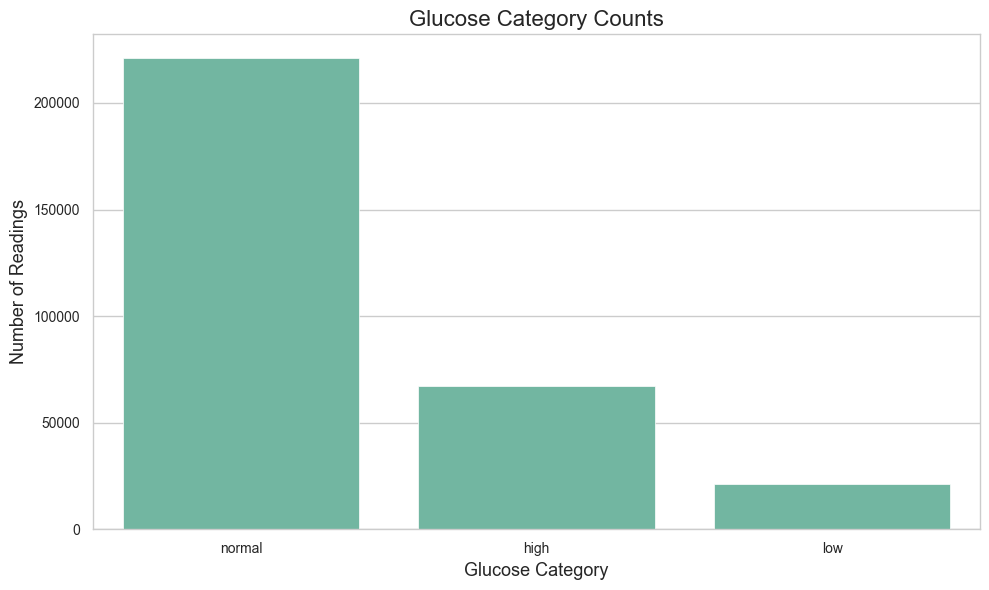

In [132]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="glucose_category",
    order=df["glucose_category"].value_counts().index
)

plt.title("Glucose Category Counts")
plt.xlabel("Glucose Category")
plt.ylabel("Number of Readings")

plt.tight_layout()
plt.savefig(f"{plots_dir}/glucose_category_counts.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

This plot shows how glucose readings are distributed across categories. If normal readings dominate, it may suggest that most observations are within a stable glucose range. If high or very high categories are frequent, it may indicate that hyperglycemia is common in the dataset.

This categorical view makes the glucose data easier to interpret compared with raw numerical values alone.

### Why this step is important

Glucose categories provide a more interpretable view of glucose control. They help translate numerical values into meaningful health-related groups.

### Consequence if skipped

If this step is skipped, the analysis may rely only on numerical glucose values, making it harder to communicate findings to non-technical audiences.

## 9. Patient-Level Glucose Trends Over Time

This section visualizes glucose trends over time for selected patients.

Because this is a time-series dataset, it is important to observe how glucose changes across time for individual patients.

In [133]:
sample_patients = df["patient_id"].unique()[:3]

sample_patients

<StringArray>
['HUPA0001P', 'HUPA0002P', 'HUPA0003P']
Length: 3, dtype: str

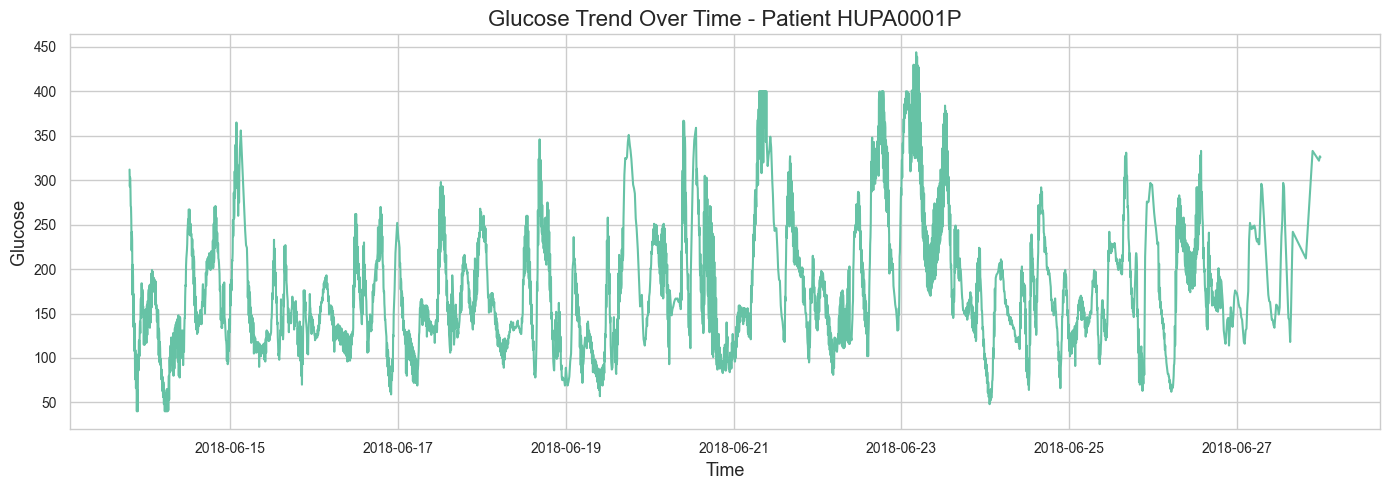

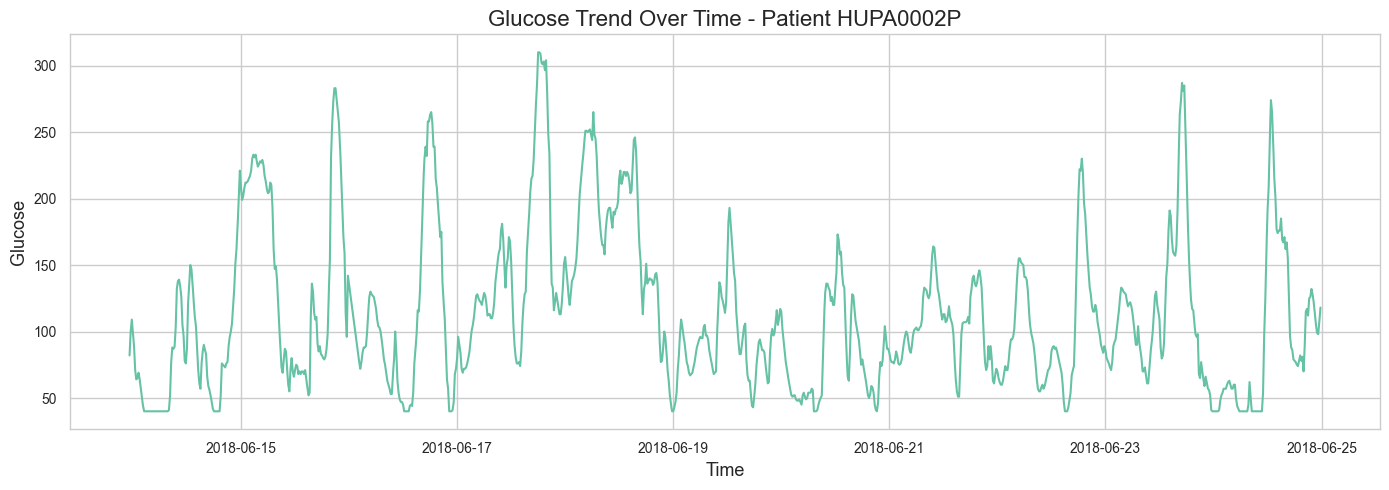

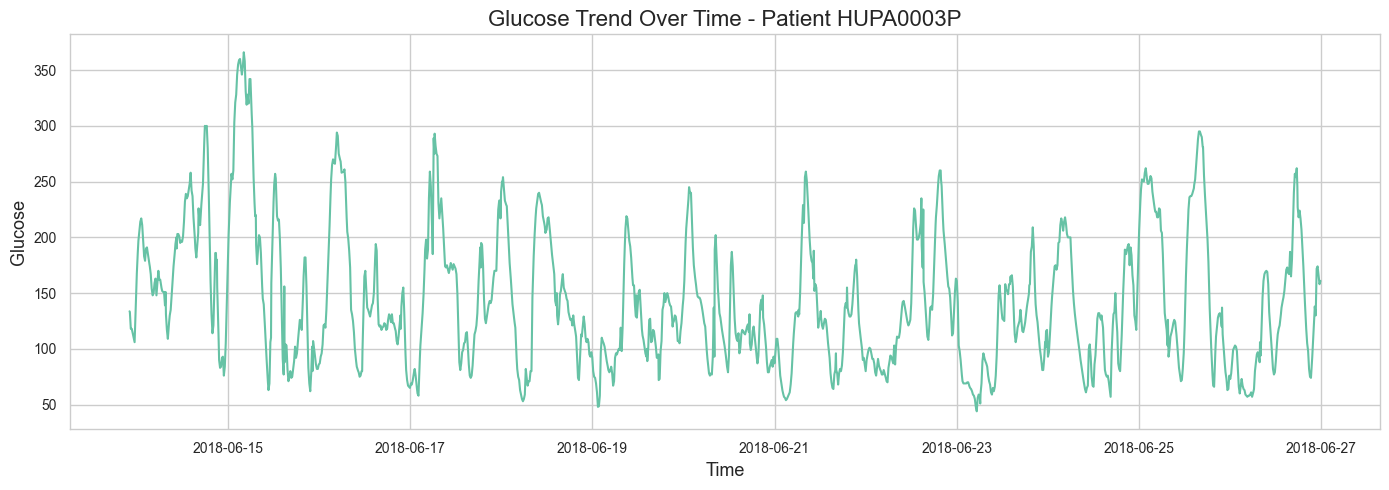

In [134]:
for patient in sample_patients:
    patient_df = df[df["patient_id"] == patient]

    plt.figure(figsize=(14, 5))
    plt.plot(patient_df["time"], patient_df["glucose"])

    plt.title(f"Glucose Trend Over Time - Patient {patient}")
    plt.xlabel("Time")
    plt.ylabel("Glucose")

    plt.tight_layout()
    plt.savefig(f"{plots_dir}/glucose_trend_patient_{patient}.png", dpi=300, bbox_inches="tight")
    plt.show()

### Interpretation

The patient-level time-series plots show that glucose values fluctuate over time. These fluctuations may be caused by meals, insulin delivery, activity levels, sleep, or individual patient behavior.

Different patients may show different patterns. Some may have relatively stable glucose values, while others may experience frequent spikes and drops.

### Why this step is important

Overall averages can hide individual patient behavior. Since diabetes management is patient-specific, viewing individual glucose trends helps reveal patterns that are not visible in aggregate analysis.

### Consequence if skipped

If patient-level time-series plots are skipped, the analysis may miss important individual differences. The project may incorrectly assume that all patients follow similar glucose patterns.

## 10. Average Glucose by Patient

This section compares average glucose levels across patients.

The goal is to identify whether some patients have consistently higher or lower glucose values than others.

In [135]:
patient_avg_glucose = df.groupby("patient_id")["glucose"].mean().sort_values()

patient_avg_glucose

patient_id
HUPA0022P    112.454872
HUPA0002P    113.534173
HUPA0025P    113.864875
HUPA0028P    128.448027
HUPA0027P    130.831137
HUPA0023P    133.187324
HUPA0010P    135.891358
HUPA0021P    137.525103
HUPA0003P    143.285113
HUPA0018P    143.742736
HUPA0005P    147.628212
HUPA0016P    150.349700
HUPA0011P    159.219106
HUPA0019P    162.881511
HUPA0026P    162.988048
HUPA0015P    163.688590
HUPA0006P    165.336471
HUPA0024P    167.112051
HUPA0007P    173.298197
HUPA0004P    180.379327
HUPA0001P    181.237775
HUPA0014P    188.099268
HUPA0009P    193.637658
HUPA0020P    194.158964
HUPA0017P    201.018114
Name: glucose, dtype: float64

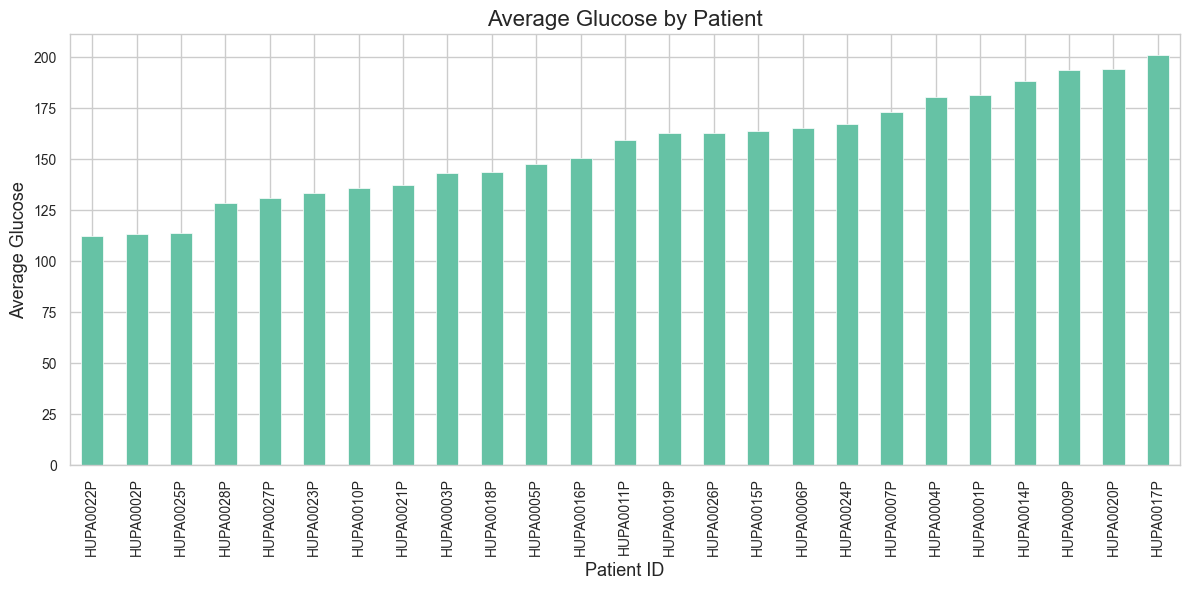

In [136]:
plt.figure(figsize=(12, 6))

patient_avg_glucose.plot(kind="bar")

plt.title("Average Glucose by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Average Glucose")

plt.tight_layout()
plt.savefig(f"{plots_dir}/average_glucose_by_patient.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Average glucose differs across patients, showing that glucose control is not the same for every individual. Patients with higher average glucose may have more frequent high glucose readings or less stable glucose control.

### Why this step is important

Patient-level averages help compare glucose control across individuals. This supports personalized analysis instead of treating the dataset as one single population.

### Consequence if skipped

If this step is skipped, patient differences may be ignored. Important variation between patients may be hidden by the overall glucose average.

## 11. Glucose Variability by Patient

This section analyzes glucose variability for each patient using standard deviation.

Average glucose alone does not fully describe glucose control. Two patients may have the same average glucose but very different levels of fluctuation.

In [137]:
patient_glucose_std = df.groupby("patient_id")["glucose"].std().sort_values()

patient_glucose_std

patient_id
HUPA0028P    35.446615
HUPA0025P    40.079341
HUPA0022P    40.360139
HUPA0023P    43.085768
HUPA0021P    45.864812
HUPA0009P    46.075067
HUPA0027P    46.267521
HUPA0005P    49.797424
HUPA0011P    57.059919
HUPA0010P    57.664698
HUPA0002P    59.182065
HUPA0019P    60.577039
HUPA0003P    61.374709
HUPA0024P    66.511990
HUPA0015P    67.963868
HUPA0026P    68.669908
HUPA0017P    69.290960
HUPA0018P    70.304005
HUPA0001P    70.490404
HUPA0014P    72.509258
HUPA0007P    78.630028
HUPA0020P    78.820455
HUPA0016P    79.819262
HUPA0004P    83.096243
HUPA0006P    84.805813
Name: glucose, dtype: float64

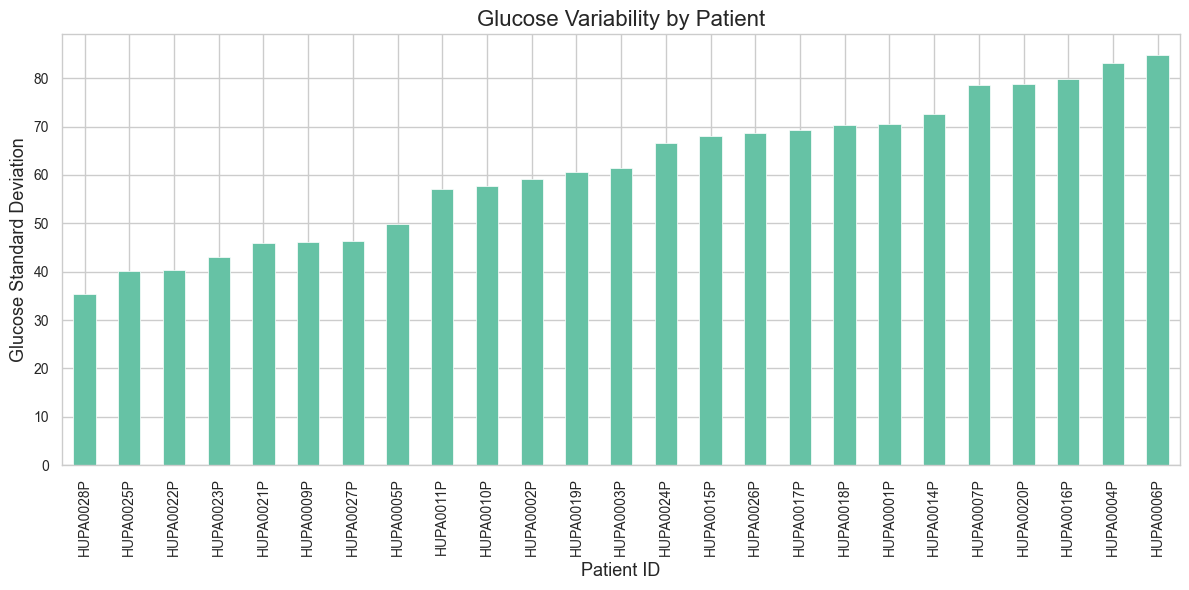

In [138]:
plt.figure(figsize=(12, 6))

patient_glucose_std.plot(kind="bar")

plt.title("Glucose Variability by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Glucose Standard Deviation")

plt.tight_layout()
plt.savefig(f"{plots_dir}/glucose_variability_by_patient.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Patients with higher glucose standard deviation experience greater glucose fluctuations. This may suggest less stable glucose control.

A patient with moderate average glucose but high variability may still experience frequent spikes and drops, which can be clinically important.

### Why this step is important

Glucose variability is an important part of time-series diabetes analysis. It provides additional information beyond average glucose.

### Consequence if skipped

If variability is skipped, the analysis may overlook patients who appear normal on average but experience unstable glucose patterns.

## 12. Average Glucose by Hour of Day

This section analyzes how average glucose changes by hour of the day.

The goal is to identify whether glucose tends to be higher or lower during certain parts of the day.

In [139]:
hourly_glucose = df.groupby("hour")["glucose"].mean()

hourly_glucose

hour
0     142.591565
1     138.740442
2     137.456326
3     138.166504
4     139.117531
5     138.296633
6     136.677204
7     135.232969
8     136.351311
9     140.178077
10    147.361706
11    148.195308
12    140.603558
13    133.165216
14    130.749927
15    136.680548
16    137.048424
17    138.742373
18    146.112460
19    152.534423
20    150.592129
21    150.671067
22    151.377167
23    147.389218
Name: glucose, dtype: float64

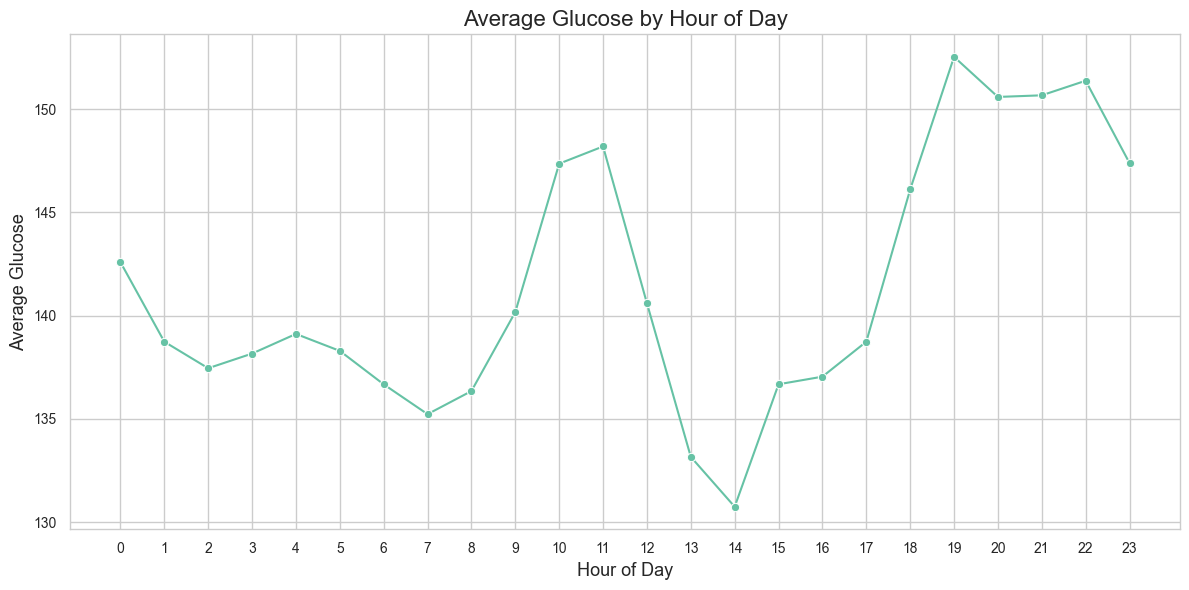

In [140]:
plt.figure(figsize=(12, 6))

sns.lineplot(x=hourly_glucose.index, y=hourly_glucose.values, marker="o")

plt.title("Average Glucose by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Glucose")
plt.xticks(range(0, 24))

plt.tight_layout()
plt.savefig(f"{plots_dir}/average_glucose_by_hour.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The hourly glucose pattern shows how glucose levels vary throughout the day. Higher values during certain hours may be related to meals, insulin timing, activity patterns, or overnight glucose behavior.

This analysis helps identify daily glucose trends that may not be visible in the overall distribution.

### Why this step is important

Glucose is time-dependent. Analyzing glucose by hour helps reveal daily patterns and possible periods of higher glucose risk.

### Consequence if skipped

If hourly analysis is skipped, the project may miss important time-of-day effects in glucose behavior.

## 13. Glucose Distribution by Day of Week

This section compares glucose values across different days of the week.

A boxplot is used to show the median, spread, and possible outliers for each day.

In [141]:
print(df_plot.shape)
print(df_plot["day_of_week"].value_counts(dropna=False))
print(df_plot["glucose"].describe())

(309242, 21)
day_of_week
Saturday     44851
Friday       44811
Thursday     44807
Tuesday      44271
Sunday       44060
Monday       43931
Wednesday    42511
Name: count, dtype: int64
count    309242.000000
mean        141.430195
std          57.077809
min          40.000000
25%          99.666667
50%         132.000000
75%         173.000000
max         444.000000
Name: glucose, dtype: float64


In [142]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

In [143]:
df_plot.shape

(309242, 21)

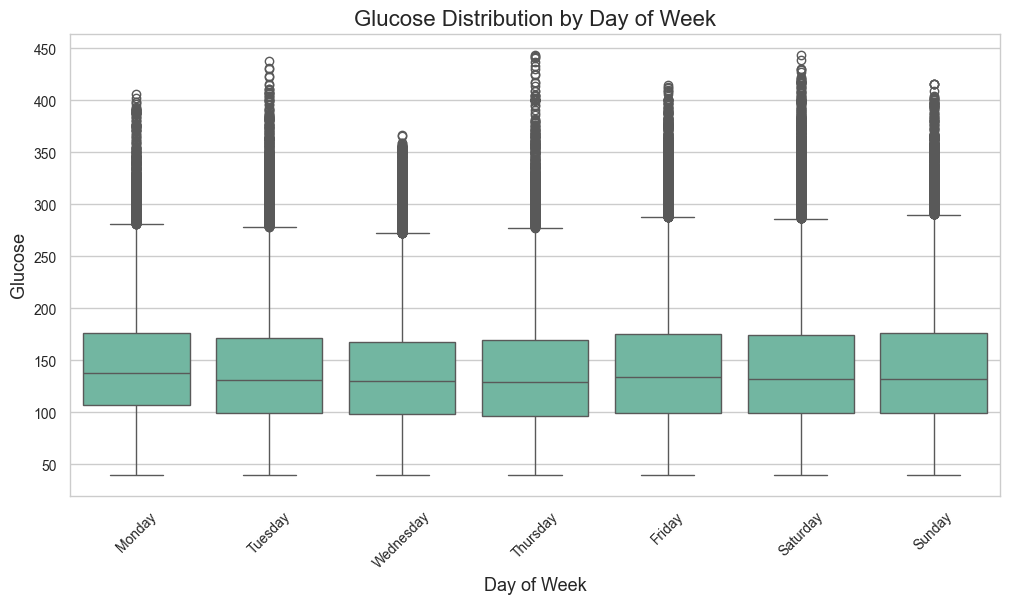

In [144]:
df["time"] = pd.to_datetime(df["time"])

df["day_of_week"] = df["time"].dt.day_name()

df_plot = df.dropna(subset=["day_of_week", "glucose"]).copy()

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_plot,
    x="day_of_week",
    y="glucose",
    order=weekday_order
)

plt.title("Glucose Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Glucose")
plt.xticks(rotation=45)
plt.show()

### Observations

- Median glucose levels appear relatively consistent across all weekdays.
- Variability in glucose levels is similar throughout the week.
- All weekdays show a significant number of high-glucose outliers.
- Weekend days do not appear drastically different from weekdays.
- Several extreme glucose spikes above 350–400 are visible, indicating possible hyperglycemic events.

### Interpretation

The day-of-week boxplot shows whether glucose behavior changes across the week. Wider boxes indicate greater variability, while outliers show unusually high or low glucose values.

Differences between weekdays and weekends may reflect changes in routine, meals, activity, or insulin use.

### Why this step is important

Day-of-week analysis helps identify whether glucose patterns are affected by weekly routines.

### Consequence if skipped

If this step is skipped, possible weekday versus weekend patterns may be missed.

## 14. Correlation Analysis

This section analyzes linear relationships between glucose and other numerical features.

The correlation heatmap includes:

- glucose
- heart rate
- calories
- steps
- basal rate
- bolus insulin
- carbohydrate input

In [145]:
numeric_cols = [
    "glucose",
    "heart_rate",
    "calories",
    "steps",
    "basal_rate",
    "bolus_volume_delivered",
    "carb_input"
]

corr_matrix = df[numeric_cols].corr()

corr_matrix

,glucose,heart_rate,calories,steps,basal_rate,bolus_volume_delivered,carb_input
glucose,1.000000,0.098395,0.008571,0.051336,-0.022837,0.020141,-0.001037
heart_rate,0.098395,1.000000,0.570772,0.499427,-0.069814,0.021565,0.000342
calories,0.008571,0.570772,1.000000,0.802900,0.054643,0.023444,0.011799
steps,0.051336,0.499427,0.802900,1.000000,0.008471,0.011800,0.003409
basal_rate,-0.022837,-0.069814,0.054643,0.008471,1.000000,0.016654,0.026762
bolus_volume_delivered,0.020141,0.021565,0.023444,0.011800,0.016654,1.000000,0.169762
carb_input,-0.001037,0.000342,0.011799,0.003409,0.026762,0.169762,1.000000


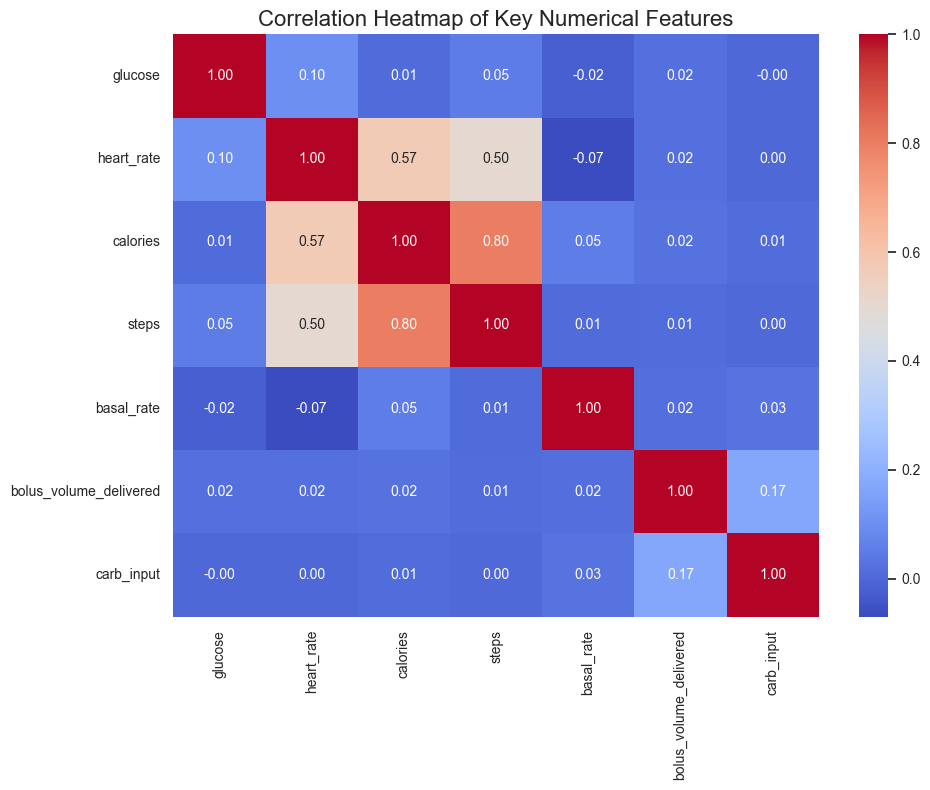

In [146]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Key Numerical Features")

plt.tight_layout()
plt.savefig(f"{plots_dir}/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The correlation heatmap shows the strength and direction of linear relationships between numerical variables.

A weak correlation with glucose does not necessarily mean a feature is unimportant. In diabetes time-series data, the effects of meals, insulin, and activity may occur after a delay rather than at the exact same timestamp.

### Why this step is important

Correlation analysis provides a quick way to understand relationships between variables and identify possible features for future modeling.

### Consequence if skipped

If correlation analysis is skipped, the project may miss important relationships between features. However, correlation should not be treated as final proof because it only captures linear same-time relationships.

## 15. Glucose vs Steps

This section explores the relationship between physical activity and glucose levels.

A scatterplot is used to compare step count and glucose values.

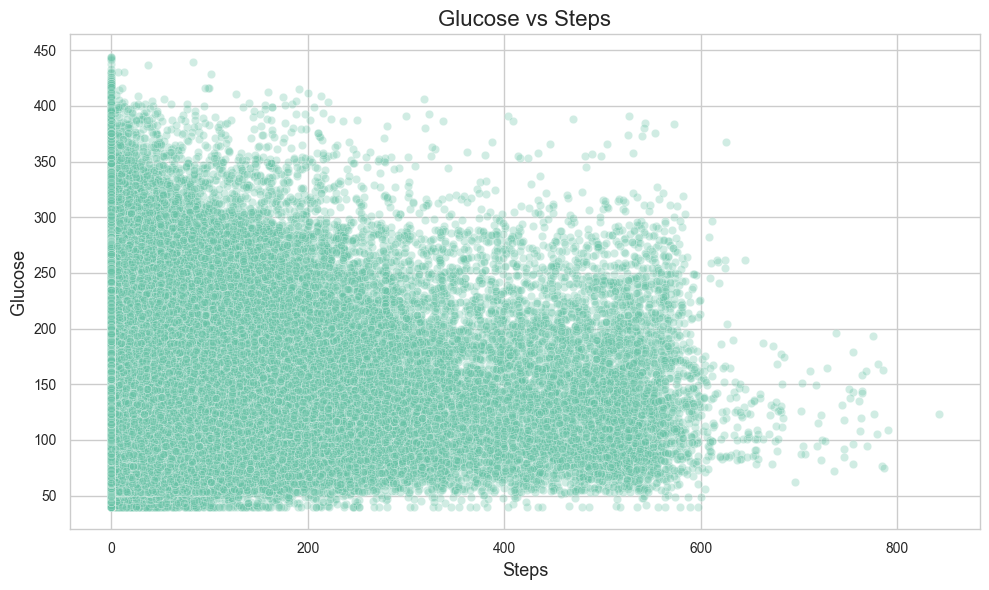

In [147]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="steps",
    y="glucose",
    alpha=0.3
)

plt.title("Glucose vs Steps")
plt.xlabel("Steps")
plt.ylabel("Glucose")

plt.tight_layout()
plt.savefig(f"{plots_dir}/glucose_vs_steps.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

This scatterplot explores whether physical activity is associated with glucose levels. A strong linear relationship may not appear because glucose response to activity can vary by patient and may occur after a delay.

Physical activity may also affect glucose differently depending on insulin levels, food intake, and patient-specific factors.

### Why this step is important

Steps represent physical activity, which may influence glucose behavior. Exploring this relationship helps determine whether activity-related features may be useful later.

### Consequence if skipped

If this step is skipped, the analysis may miss possible activity-related glucose patterns.

## 16. Glucose vs Carbohydrate Input

This section explores the relationship between carbohydrate intake and glucose values.

Carbohydrate intake is an important diabetes-related feature because food intake can influence glucose levels.

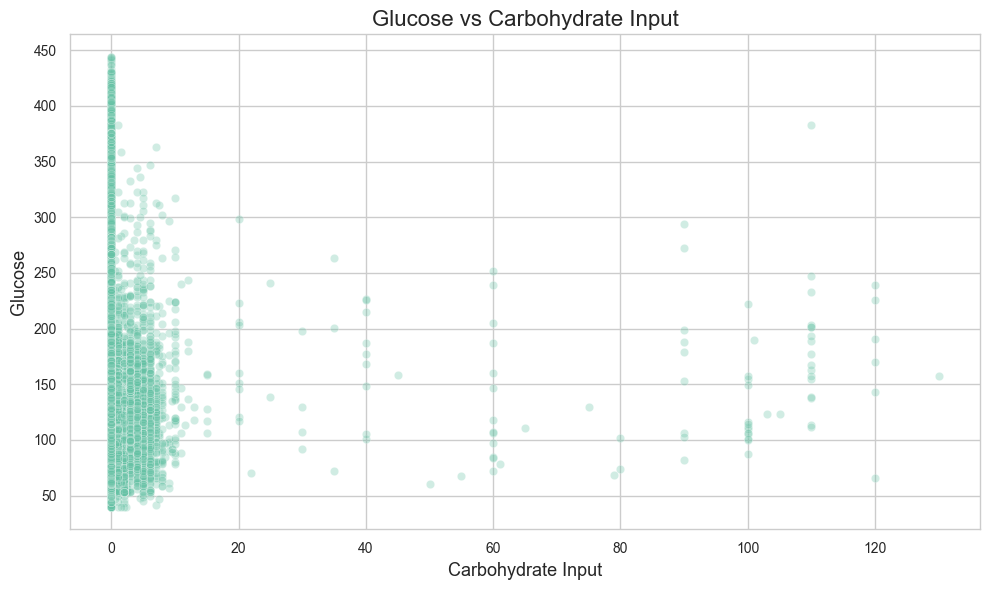

In [148]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="carb_input",
    y="glucose",
    alpha=0.3
)

plt.title("Glucose vs Carbohydrate Input")
plt.xlabel("Carbohydrate Input")
plt.ylabel("Glucose")

plt.tight_layout()
plt.savefig(f"{plots_dir}/glucose_vs_carb_input.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Carbohydrate intake is expected to influence glucose levels, but the relationship may not appear strongly at the exact same timestamp. Glucose often rises after a delay following carbohydrate intake.

This means lag-based analysis may be more useful than same-time scatterplots for understanding the effect of carbohydrates.

### Interpretation

Carbohydrate intake is expected to influence glucose levels, but the relationship may not appear strongly at the exact same timestamp. Glucose often rises after a delay following carbohydrate intake.

This means lag-based analysis may be more useful than same-time scatterplots for understanding the effect of carbohydrates.

## 17. Glucose vs Bolus Insulin Delivered

This section explores the relationship between glucose and bolus insulin delivery.

Bolus insulin is often given around meals or in response to elevated glucose levels.

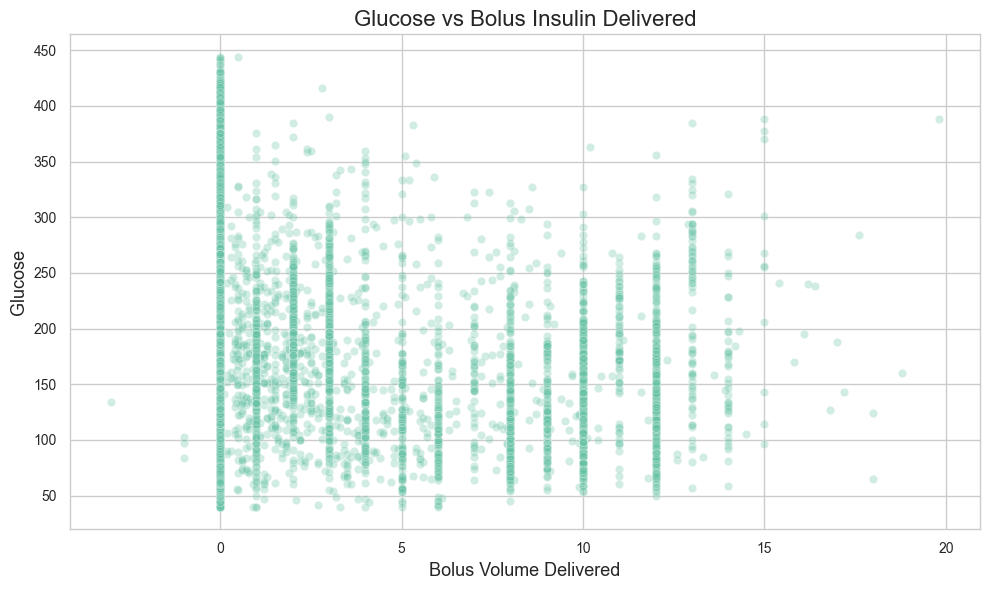

In [149]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="bolus_volume_delivered",
    y="glucose",
    alpha=0.3
)

plt.title("Glucose vs Bolus Insulin Delivered")
plt.xlabel("Bolus Volume Delivered")
plt.ylabel("Glucose")

plt.tight_layout()
plt.savefig(f"{plots_dir}/glucose_vs_bolus_insulin.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Bolus insulin may appear related to glucose because insulin is often delivered in response to meals or high glucose values. However, the effect of insulin is not immediate.

This plot should be interpreted carefully because it may reflect treatment behavior rather than a direct same-time effect.

### Why this step is important

Insulin delivery is a key diabetes management feature. Understanding its relationship with glucose is important for later predictive modeling or clinical interpretation.

### Consequence if skipped

If this step is skipped, the analysis may fail to explore an important treatment-related variable.

## 18. Lag Feature Analysis

This section analyzes lagged glucose features created during preprocessing.

Lag features represent previous glucose readings. Since glucose is a time-series signal, previous glucose values are expected to be strongly related to current glucose.

In [150]:
lag_cols = [col for col in df.columns if "glucose_lag" in col]

lag_cols

['glucose_lag_1', 'glucose_lag_3', 'glucose_lag_6']

In [151]:
if lag_cols:
    lag_corr = df[["glucose"] + lag_cols].corr()
    lag_corr
else:
    print("No glucose lag columns found.")

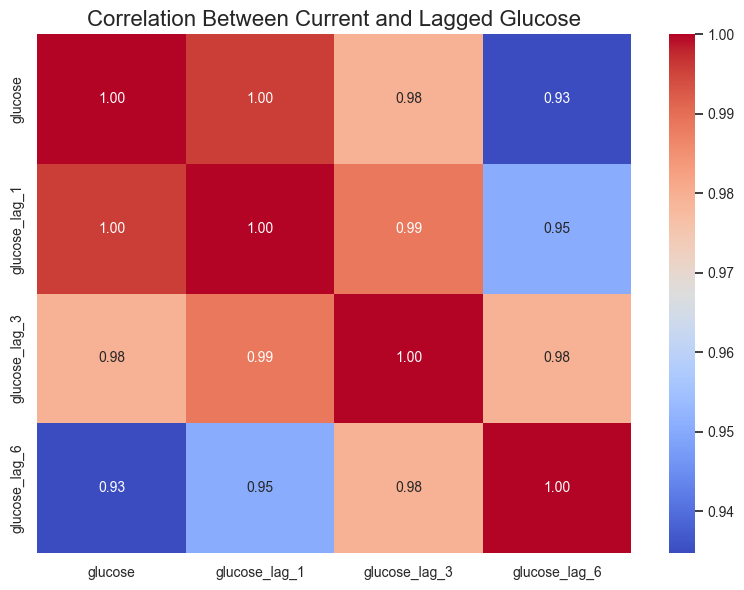

In [152]:
if lag_cols:
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        lag_corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Between Current and Lagged Glucose")

    plt.tight_layout()
    plt.savefig(f"{plots_dir}/glucose_lag_correlation.png", dpi=300, bbox_inches="tight")
    plt.show()

### Interpretation

Lagged glucose values are expected to have strong correlation with current glucose. This is because glucose changes gradually over time and previous readings contain useful information about current and future glucose levels.

Strong lag correlations support the importance of using lag features in future predictive modeling.

### Why this step is important

Lag features are especially important for time-series datasets. They help capture temporal dependency and make future prediction more realistic.

### Consequence if skipped

If lag analysis is skipped, the project may miss one of the strongest sources of predictive information in the dataset.

## 19. Rolling Glucose Feature Analysis

This section analyzes rolling glucose features created during preprocessing.

Rolling features summarize recent glucose behavior over a time window. These features can represent short-term trends and variability.

In [153]:
rolling_cols = [col for col in df.columns if "rolling" in col.lower()]

rolling_cols

['glucose_rolling_30min', 'glucose_rolling_1hr']

In [154]:
if rolling_cols:
    df[["glucose"] + rolling_cols].describe()
else:
    print("No rolling glucose columns found.")

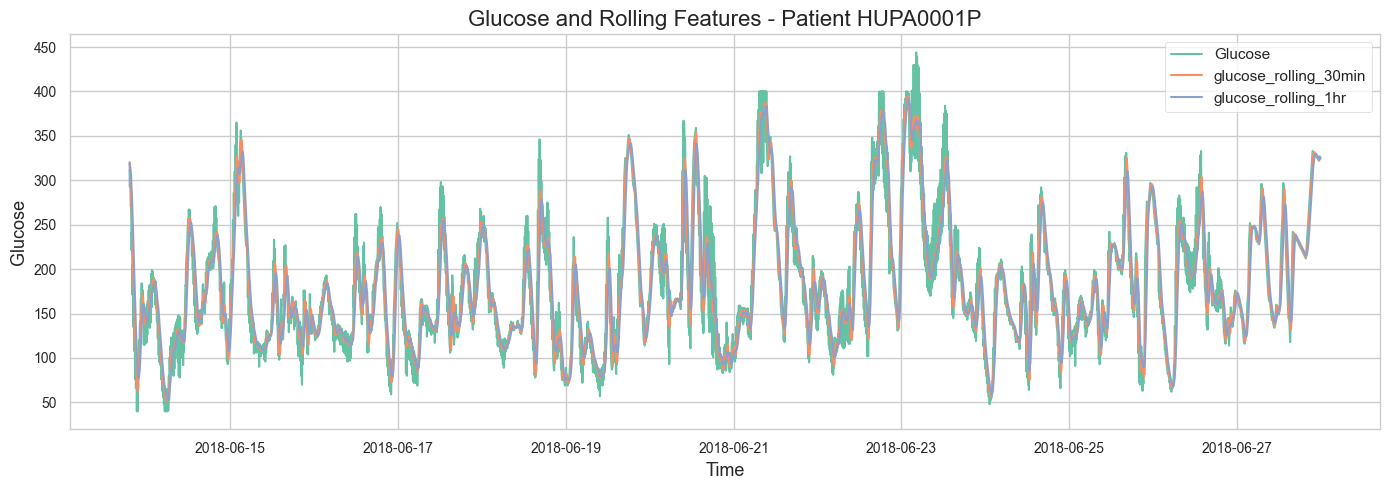

In [155]:
if rolling_cols:
    sample_patient = df["patient_id"].unique()[0]
    patient_df = df[df["patient_id"] == sample_patient]

    plt.figure(figsize=(14, 5))

    plt.plot(patient_df["time"], patient_df["glucose"], label="Glucose")

    for col in rolling_cols[:2]:
        plt.plot(patient_df["time"], patient_df[col], label=col)

    plt.title(f"Glucose and Rolling Features - Patient {sample_patient}")
    plt.xlabel("Time")
    plt.ylabel("Glucose")
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{plots_dir}/rolling_features_patient_{sample_patient}.png", dpi=300, bbox_inches="tight")
    plt.show()

### Interpretation

Rolling glucose features smooth short-term fluctuations and help capture recent glucose trends. They can show whether glucose has been stable, increasing, or decreasing over recent time windows.

These features may be useful in future modeling because they provide more context than a single glucose reading.

### Why this step is important

Rolling features help summarize recent time-series behavior. This is useful because glucose patterns depend not only on the current reading but also on recent trends.

### Consequence if skipped

If rolling feature analysis is skipped, the project may miss useful information about short-term glucose stability and trends.

## 20. Patient Summary Analysis

This section uses the patient-level summary file created in Notebook 2.

The goal is to examine patient-level differences using summarized metrics.

In [156]:
print(patient_summary.shape)
patient_summary.head()

(25, 7)


,patient_id,start_time,end_time,total_records,avg_glucose,min_glucose,max_glucose
0,HUPA0001P,2018-06-13 19:10:00,2018-06-27 23:55:00,4090,181.237775,40.0,444.0
1,HUPA0002P,2018-06-13 23:15:00,2018-06-24 23:45:00,3175,113.534173,40.0,310.0
2,HUPA0003P,2018-06-13 22:10:00,2018-06-26 23:45:00,3764,143.285113,44.0,366.0
3,HUPA0004P,2018-07-09 16:00:00,2018-07-20 16:45:00,3178,180.379327,40.0,411.0
4,HUPA0005P,2018-07-09 14:50:00,2018-07-22 23:45:00,3852,147.628212,40.0,379.0


In [157]:
print(patient_summary.columns)

Index(['patient_id', 'start_time', 'end_time', 'total_records', 'avg_glucose',
       'min_glucose', 'max_glucose'],
      dtype='str')


In [158]:
patient_summary.describe()

,total_records,avg_glucose,min_glucose,max_glucose
count,25.000000,25.000000,25.000000,25.000000
mean,12369.680000,155.351908,44.000000,364.180000
std,32975.073076,26.119537,12.186058,54.345515
min,2284.000000,112.454872,40.000000,245.000000
25%,3178.000000,135.891358,40.000000,310.000000
50%,3823.000000,159.219106,40.000000,370.000000
75%,3913.000000,173.298197,42.000000,401.000000
max,165300.000000,201.018114,100.000000,444.000000


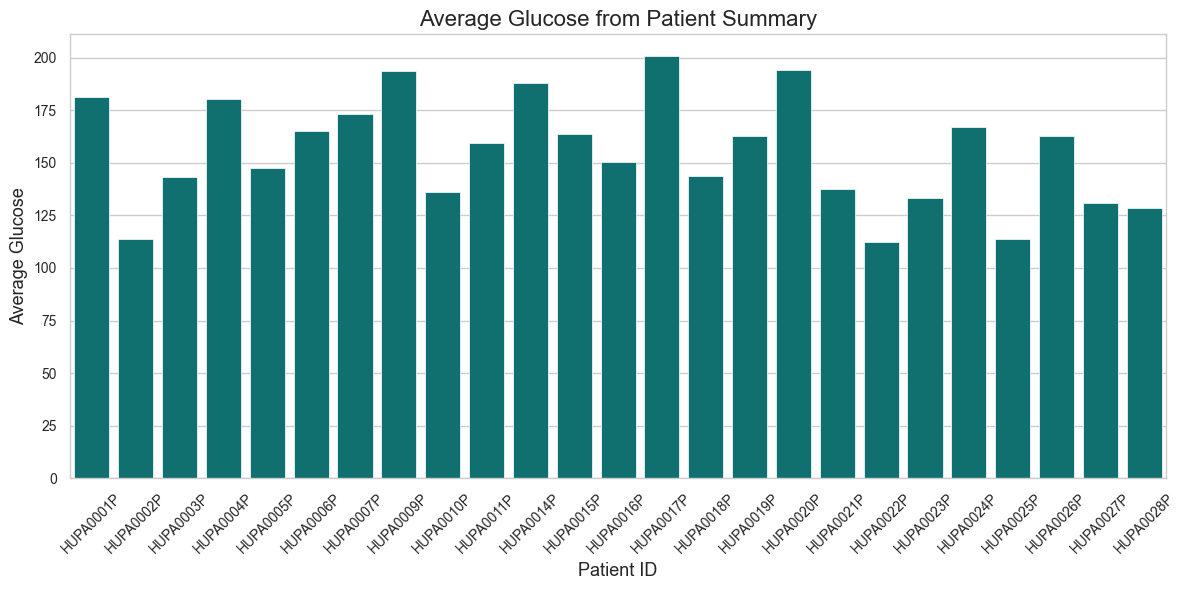

In [159]:
if "avg_glucose" in patient_summary.columns:
    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=patient_summary,
        x="patient_id",
        y="avg_glucose",
        color="teal"
    )

    plt.title("Average Glucose from Patient Summary")
    plt.xlabel("Patient ID")
    plt.ylabel("Average Glucose")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.savefig(f"{plots_dir}/patient_summary_avg_glucose.png", dpi=300, bbox_inches="tight")
    plt.show()

### Interpretation

The patient summary dataset provides a compact view of patient-level glucose behavior. It helps compare patients without needing to inspect every timestamped record.

This summary is useful for identifying patients with higher average glucose, greater variability, or other notable patterns.

### Why this step is important

Patient-level summaries make the analysis easier to interpret and communicate. They help move from row-level data to patient-level insights.

### Consequence if skipped

If patient summary analysis is skipped, the notebook may rely too much on raw time-series records and miss high-level patient comparisons.

## 21. Key Findings

The exploratory data analysis produced the following findings:

1. Glucose values show meaningful variation across the dataset.
2. Glucose readings can be grouped into clinically meaningful categories.
3. Patient-level analysis shows differences in average glucose across individuals.
4. Glucose variability differs by patient, suggesting that some patients have more unstable glucose patterns.
5. Time-based analysis shows that glucose may vary by hour of day and day of week.
6. Same-time correlations between glucose and behavioral or treatment features may be limited.
7. Lagged glucose features are strongly relevant because glucose is time-dependent.
8. Rolling glucose features provide useful context about recent glucose trends and stability.

### Why this step is important

Key findings summarize the main insights from the notebook. This helps the reader understand the analytical results without reviewing every plot in detail.

### Consequence if skipped

If key findings are skipped, the notebook may feel incomplete. The reader may see charts but not understand the main conclusions.

## 22. Analytical Storytelling

This dataset represents continuous glucose monitoring and related diabetes management signals across multiple patients.

The analysis shows that glucose behavior is highly time-dependent and patient-specific. Overall glucose distributions provide a useful starting point, but they do not fully explain individual patient behavior.

Patient-level analysis shows that average glucose and glucose variability differ across individuals. This suggests that diabetes management patterns vary from patient to patient.

Time-based analysis shows that glucose levels may change across hours of the day and days of the week. These changes may reflect meals, insulin use, physical activity, sleep, and routine differences.

Correlation analysis shows that same-time relationships between glucose and other features may be limited. This is expected because glucose response to carbohydrates, insulin, and activity often occurs with a delay.

Lag and rolling glucose features are especially important because they capture time-series behavior. These features may be valuable for future predictive modeling.

### Why this step is important

Analytical storytelling connects the individual charts into one clear explanation. This makes the notebook more professional and portfolio-ready.

### Consequence if skipped

If storytelling is skipped, the notebook may look technical but not analytical. A reviewer may not understand the bigger picture or why the analysis matters.

## 23. Challenges

Several challenges were identified during exploratory analysis:

- The dataset contains multiple patients with different glucose patterns.
- Glucose is a time-series variable, so time order must be preserved.
- Same-time relationships may not capture delayed physiological effects.
- Carbohydrate intake, insulin delivery, and activity may influence glucose after a delay.
- Visualizing all patients at once can become difficult due to dataset size.
- Patient-level differences make it difficult to generalize from overall averages alone.

### Why this step is important

Documenting challenges shows that the analysis was performed thoughtfully. It also explains why some relationships may not be obvious in simple plots.

### Consequence if skipped

If challenges are skipped, the notebook may appear to ignore important limitations of time-series diabetes data.

## 24. Next Steps

The next phase of the project can focus on deeper analysis and modeling preparation.

Possible next steps include:

- perform more detailed patient-specific analysis
- compare glucose categories across patients
- analyze delayed effects of carbohydrate intake, insulin, and activity
- create additional time-window features
- prepare the dataset for predictive modeling
- build models to predict future glucose values
- evaluate model performance at patient level

### Why this step is important

Next steps show how this notebook connects to the future direction of the project. This helps make the project look complete and well-planned.

### Consequence if skipped

If next steps are skipped, the project may feel unfinished and disconnected from future modeling or deeper analysis.

## 25. Notebook 3 Completion Checklist

This notebook completed the following steps:

- Loaded the processed dataset
- Verified dataset structure
- Converted time column to datetime
- Created a folder for saving visualizations
- Reviewed dataset overview statistics
- Analyzed glucose distribution
- Analyzed glucose category counts
- Visualized patient-level glucose trends
- Compared average glucose by patient
- Compared glucose variability by patient
- Analyzed hourly glucose patterns
- Analyzed day-of-week glucose patterns
- Performed correlation analysis
- Explored glucose relationships with steps, carbohydrates, and insulin
- Reviewed lag glucose features
- Reviewed rolling glucose features
- Analyzed patient-level summary data
- Saved plots professionally
- Documented key findings, challenges, and next steps